# 00: Validação do Canal Rayleigh (Card 1)

Este notebook **valida** o canal entregue no Card 1 (que os cards 2-4 vão
usar). Regra do TAREFAS: *código sem explicação não conta como
entregue*; cada seção declara o que verifica e por quê.

Convenção de seeds: `sionna.phy.config.seed` (o único mecanismo canônico).
`torch.manual_seed` não controla o canal (verificado na seção P8).


In [1]:
# Setup: imports + versões (reprodutibilidade bit-a-bit depende de versões)
import os
import sys

# O kernel inicia em notebooks/ (jupyter lab e nbconvert): garantir que a
# raiz do repo esteja no path para `import src` funcionar nos dois fluxos.
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if os.path.isdir(os.path.join(ROOT, "src")) and ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import torch
import matplotlib.pyplot as plt
import scipy.stats as stats
import sionna
from sionna.phy import config as sionna_config
from sionna.phy.channel import RayleighBlockFading
from sionna.phy.ofdm import ResourceGrid
from sionna.phy.channel import GenerateOFDMChannel

from src.channel import generate_channel, compute_rates
from src.config import load_config

%matplotlib inline
print("sionna:", sionna.__version__, "| torch:", torch.__version__)
cfg = load_config()
print("cfg:", cfg.channel_model, cfg.num_prbs, "PRBs |", cfg.subcarrier_spacing_hz/1e3, "kHz |", cfg.occupied_bandwidth_hz/1e6, "MHz")


sionna: 2.0.1 | torch: 2.13.0+cpu
cfg: rayleigh 52 PRBs | 30.0 kHz | 18.72 MHz


## Contrato de API: o notebook quebra se src/channel.py mudar de interface

In [2]:
import inspect
from src.channel import generate_channel as gc, compute_rates as cr
sig_gen = inspect.signature(gc)
sig_rates = inspect.signature(cr)
print("generate_channel:", sig_gen)
print("compute_rates:", sig_rates)
assert "seed" in sig_gen.parameters and "num_ues" in sig_gen.parameters
assert cfg.channel_model == "rayleigh"


generate_channel: (seed: 'int', num_ues: 'int', num_ttis: 'int', *, precision: 'str' = 'single', device: 'str | None' = None) -> 'ChannelRealization'
compute_rates: (cfg: 'Config', h: 'np.ndarray') -> 'np.ndarray'


## P1: Magnitude do fading é Rayleigh

Sionna gera Re, Im ~ N(0, 0.5) (fonte v2.0.1), logo E[|h|²]=1 e
E[|h|] = √(π/2)·(1/√2) = √π/2 ≈ 0.8862. O critério são os **momentos** (±1%);
KS/AD entram no relatório como evidência reportada (com n grande ficam
hipersensíveis).

E|h| = 0.8863 (teorico 0.8862)
E|h|^2 = 1.0009 (teorico 1.0)
mediana |h| = 0.8328 (teorico 0.8326)


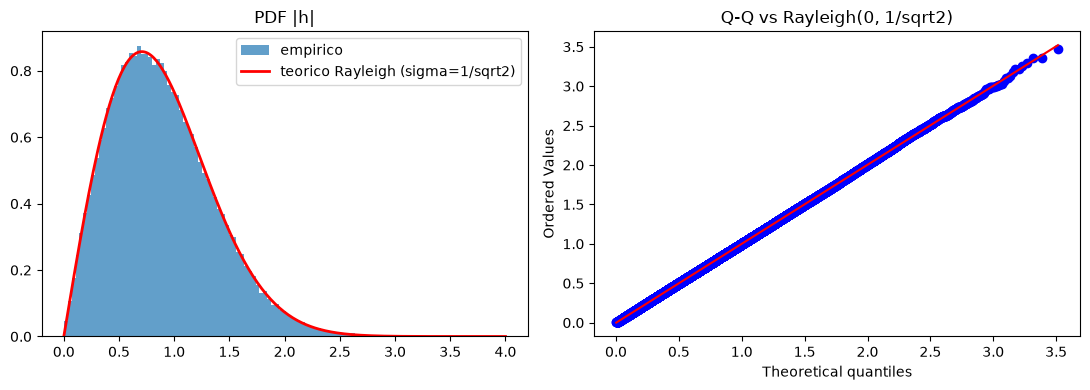

KS p-value (reportado, nao criterio): 9.58e-01


In [3]:
r = generate_channel(seed=0, num_ues=8, num_ttis=20000)
h = r.h.flatten()
mag = np.abs(h)

mean_mag = mag.mean()
mean_sq = (mag**2).mean()
median_mag = np.median(mag)
print(f"E|h| = {mean_mag:.4f} (teorico {np.sqrt(np.pi)/2:.4f})")
print(f"E|h|^2 = {mean_sq:.4f} (teorico 1.0)")
print(f"mediana |h| = {median_mag:.4f} (teorico {np.sqrt(np.log(2)):.4f})")
assert abs(mean_mag - np.sqrt(np.pi)/2) < 0.01
assert abs(mean_sq - 1.0) < 0.01
assert abs(median_mag - np.sqrt(np.log(2))) < 0.02

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.linspace(0, 4, 300)
axes[0].hist(mag, bins=100, density=True, alpha=0.7, label="empirico")
axes[0].plot(x, 2*x*np.exp(-x**2), "r-", lw=2, label="teorico Rayleigh (sigma=1/sqrt2)")
axes[0].set_title("PDF |h|")
axes[0].legend()
stats.probplot(mag, dist="rayleigh", sparams=(0, 1/np.sqrt(2)), plot=axes[1])
axes[1].set_title("Q-Q vs Rayleigh(0, 1/sqrt2)")
plt.tight_layout(); plt.show()

ks = stats.kstest(mag, "rayleigh", args=(0, 1/np.sqrt(2)))
print("KS p-value (reportado, nao criterio):", f"{ks.pvalue:.2e}")


## P2: Fading gaussiano complexo próprio

E[h] = -0.0016-0.0039j | Var(Re)=0.5005 Var(Im)=0.5004 | Cov(Re,Im)=0.0014


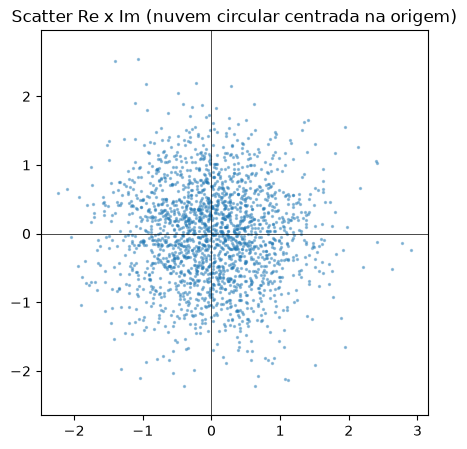

In [4]:
h = r.h.flatten()
print(f"E[h] = {h.mean():.4f} | Var(Re)={h.real.var():.4f} Var(Im)={h.imag.var():.4f} | Cov(Re,Im)={np.cov(h.real, h.imag)[0,1]:.4f}")
assert abs(h.mean()) < 0.02
assert abs(h.real.var() - 0.5) < 0.05 and abs(h.imag.var() - 0.5) < 0.05
assert abs(np.cov(h.real, h.imag)[0,1]) < 0.02
assert abs(np.mean(h**2)) < 0.05  # properness: E[h^2]=0

plt.figure(figsize=(5,5))
plt.scatter(h.real[:2000], h.imag[:2000], s=2, alpha=0.4)
plt.axhline(0, color="k", lw=0.5); plt.axvline(0, color="k", lw=0.5)
plt.axis("equal"); plt.title("Scatter Re x Im (nuvem circular centrada na origem)")
plt.show()


## P3: tau é caminho único com delay zero (base da resposta plana em frequência)

In [5]:
assert r.tau.shape == (r.num_ttis, r.num_ues, 1)
assert np.all(r.tau == 0.0)
print("tau zeros OK")


tau zeros OK


## P4: Block fading, coeficiente constante dentro da chamada

Uma chamada com `num_time_steps=N` replica o mesmo coeficiente (h.expand).
Por isso o padrão de produção não pode usar `num_time_steps=num_ttis`;
isso congelaria o canal na seed inteira.

In [6]:
sionna_config.seed = 3
m = RayleighBlockFading(num_rx=4, num_rx_ant=1, num_tx=1, num_tx_ant=1)
a, _ = m(batch_size=5, num_time_steps=14)
same = torch.allclose(a[:, 0, 0, 0, 0, 0, 0], a[:, 0, 0, 0, 0, 0, 13])
assert same
print("block fading: coeficiente constante nos 14 time steps OK")


block fading: coeficiente constante nos 14 time steps OK


## P5: Padrão de produção, batch=TTIs com num_time_steps=1, TTIs i.i.d.

Este é o padrão que src/channel.py usa: cada TTI é um exemplo de batch
independente. Sem isso, não há diversidade multiusuário temporal.

In [7]:
import time
t0 = time.perf_counter()
r_big = generate_channel(seed=42, num_ues=32, num_ttis=cfg.num_ttis)
dt = time.perf_counter() - t0
h = r_big.h
assert h.shape == (cfg.num_ttis, 32)
# TTIs consecutivos são independentes (i.i.d.)
ttis_iid = not np.allclose(h[0], h[1])
assert ttis_iid
print(f"h={h.shape} complex64 = {h.nbytes/1e6:.2f} MB | gerado em {dt:.3f}s")
print(f"Extrapolacao: 5 cargas x 20 seeds = {5*20*dt:.1f}s de geracao de canal no grid inteiro")


h=(10000, 32) complex64 = 2.56 MB | gerado em 0.003s
Extrapolacao: 5 cargas x 20 seeds = 0.3s de geracao de canal no grid inteiro


## P6: SNR homogênea entre UEs por construção

Sem path loss, E[SNR_i] = P·E[|h_i|²]/N₀ é idêntico para todo UE. A
variabilidade instantânea é grande (std de 10log10 SNR ≈ 5.57 dB, que o
Max C/I explora), mas a média temporal por UE tem SE ≈ 0.056 dB com 10⁴
TTIs. Critério: spread entre médias < 0.3 dB (~5 SE).

SNR media por UE: [10.076 10.087  9.956 10.008  9.988  9.996 10.023 10.     9.971 10.023
 10.016 10.04   9.944 10.038 10.028 10.048  9.956  9.961 10.047  9.973
 10.031 10.003 10.     9.9   10.122 10.011 10.008  9.92  10.083 10.024
  9.938 10.037] dB
spread max-min: 0.2214 dB (SE teorico ~0.056 dB, criterio < 0.3 dB)


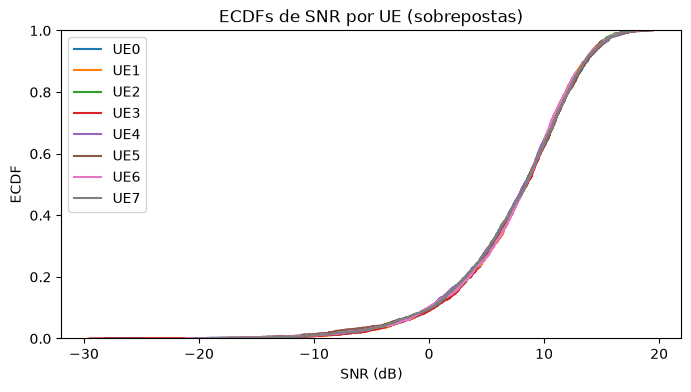

In [8]:
snr_db = r_big.snr_db(cfg.snr_db)  # [T, N] dB
per_ue_mean = r_big.mean_snr_db_per_ue(cfg.snr_db)  # média linear -> dB, por UE
spread = per_ue_mean.max() - per_ue_mean.min()
print(f"SNR media por UE: {np.round(per_ue_mean, 3)} dB")
print(f"spread max-min: {spread:.4f} dB (SE teorico ~0.056 dB, criterio < 0.3 dB)")
assert spread < 0.3

plt.figure(figsize=(8,4))
for u in range(8):
    plt.ecdf(snr_db[:2000, u], label=f"UE{u}")
plt.xlabel("SNR (dB)"); plt.ylabel("ECDF"); plt.title("ECDFs de SNR por UE (sobrepostas)")
plt.legend(); plt.show()


## P7: Independência entre UEs (base da diversidade multiusuário)

max |correlacao cruzada| entre UEs: 0.0408 (criterio < 0.1)


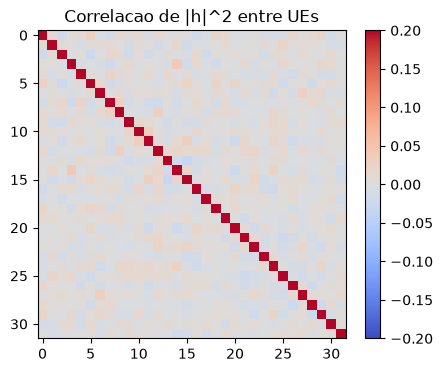

In [9]:
g = r_big.gains  # [T, N]
corr = np.corrcoef(g, rowvar=False)
off = np.abs(corr - np.eye(corr.shape[0]))
max_off = off.max()
print(f"max |correlacao cruzada| entre UEs: {max_off:.4f} (criterio < 0.1)")
assert max_off < 0.1

plt.figure(figsize=(5,4))
plt.imshow(corr, cmap="coolwarm", vmin=-0.2, vmax=0.2)
plt.colorbar(); plt.title("Correlacao de |h|^2 entre UEs")
plt.show()


## P8: Determinismo de seed

`config.seed = s` re-semeia os RNGs do Sionna (por device). Mesma seed →
bit a bit; seeds diferentes → diferentes. Esse mecanismo garante
"mesmo seed = mesmo canal" para os testes pareados do card 8.

In [10]:
a1 = generate_channel(seed=7, num_ues=4, num_ttis=256).h
a2 = generate_channel(seed=7, num_ues=4, num_ttis=256).h
b1 = generate_channel(seed=8, num_ues=4, num_ttis=256).h
assert np.array_equal(a1, a2)
assert not np.array_equal(a1, b1)
print("mesma seed -> igual (bit a bit) | seeds diferentes -> diferente OK")


mesma seed -> igual (bit a bit) | seeds diferentes -> diferente OK


## P9: Grid 2 símbolos × 12 subcarriers, resposta plana em frequência

Com 1 path e delay zero, h_freq é constante em todos os subcarriers e nos 2
símbolos. Grid completo: 52 PRBs × 12 = 624 subcarriers (18.72 MHz).
Registra a limitação do grid simplificado (não comparar absolutos com 5G NR).

In [11]:
grid = ResourceGrid(num_ofdm_symbols=2, fft_size=cfg.num_prbs*12,
                   subcarrier_spacing=cfg.subcarrier_spacing_hz,
                   num_tx=1, num_streams_per_tx=1, cyclic_prefix_length=0)
print("grid:", grid.num_effective_subcarriers, "subcarriers |", grid.num_ofdm_symbols, "simbolos | REs:", grid.num_resource_elements)
assert grid.num_effective_subcarriers == cfg.num_prbs * 12

sionna_config.seed = 9
ch_model = RayleighBlockFading(num_rx=8, num_rx_ant=1, num_tx=1, num_tx_ant=1)
gen = GenerateOFDMChannel(ch_model, grid)
h_freq = gen(32)
print("h_freq:", tuple(h_freq.shape))
flat_sym = torch.allclose(h_freq[..., 0, :], h_freq[..., 1, :], atol=1e-5)
flat_sub = torch.allclose(h_freq[..., 0], h_freq[..., 1], atol=1e-5)
assert flat_sym and flat_sub
print("plano em simbolos e subcarriers OK (1 path, delay 0)")


grid: 624 subcarriers | 2 simbolos | REs: 1248
h_freq: (32, 8, 1, 1, 1, 2, 624)
plano em simbolos e subcarriers OK (1 path, delay 0)


## Validação

Tabela check → pass/fail. O assert global só passa se tudo passou.

In [12]:
checks = {
    "P1 momentos Rayleigh": abs((np.abs(r.h).mean() - np.sqrt(np.pi)/2)) < 0.01,
    "P2 gaussiana propria": abs(r.h.real.var()-0.5) < 0.05 and abs(r.h.imag.var()-0.5) < 0.05,
    "P3 tau zero": bool(np.all(r.tau == 0)),
    "P4 block fading": bool(same),
    "P5 TTIs i.i.d. no padrao de producao": bool(ttis_iid),
    "P6 SNR homogenea (spread<0.3dB)": spread < 0.3,
    "P7 independencia UE-UE (max corr<0.1)": max_off < 0.1,
    "P8 determinismo de seed": bool(np.array_equal(a1, a2) and not np.array_equal(a1, b1)),
    "P9 grid plano 2x12 e 52 PRBs": bool(flat_sym and flat_sub),
}
for name, ok in checks.items():
    print(("PASS" if ok else "FAIL"), name)
assert all(checks.values())
print("\nCANAL VALIDADO: todas as verificacoes passaram.")


PASS P1 momentos Rayleigh
PASS P2 gaussiana propria
PASS P3 tau zero
PASS P4 block fading
PASS P5 TTIs i.i.d. no padrao de producao
PASS P6 SNR homogenea (spread<0.3dB)
PASS P7 independencia UE-UE (max corr<0.1)
PASS P8 determinismo de seed
PASS P9 grid plano 2x12 e 52 PRBs

CANAL VALIDADO: todas as verificacoes passaram.


## Conclusão

Resumo das verificações: Rayleigh com normalização correta (E|h|²=1),
gaussiana complexa própria, delay zero (plano em frequência), block fading
replicando o eixo tempo (por isso o padrão de produção usa batch=TTIs),
SNR homogênea entre UEs por construção (sem path loss, a posição não muda
a SNR média), independência UE-UE, determinismo via `config.seed` e grid
2×12 / 52 PRBs.

O canal não modela path loss, shadowing ou Doppler; é uma decisão
metodológica documentada no `config.py` (`cell_radius_m` é metadado, não
fonte de heterogeneidade). Referências: Sionna docs, TS 38.101-1 §5.3.2
(52 PRBs em 20 MHz @ 30 kHz), Jain 1984 (JFI nos cards 2+).
